# 03 Image Features and Multi-Source Data Evaluation

This notebook evaluates whether handcrafted ROI image features capture
PM2.5 variations and whether combining image, environmental, monitoring,
and temporal predictors improves PM2.5 estimation. 

The models used in this notebook serve as analytical tools for feature
and data-source evaluation. 

**Input:** `data/processed/final_dataset.csv`

**Output:** `results/feature_evaluation/`

## Research Questions

**RQ1.** Can handcrafted ROI image features effectively represent PM2.5
variations?

**RQ2.** Does multi-source data fusion improve PM2.5 estimation compared
with using ROI image features alone?


## Workflow Overview

1. Dataset preparation and feature-evaluation protocol
2. Handcrafted ROI image feature evaluation
3. Multi-source fusion and source-ablation analysis

## Setup

In [1]:
import sys
import importlib
from pathlib import Path
from scipy.stats import pearsonr, spearmanr

def find_project_root(start_path=None):
    """Find the nearest parent containing the project source and notebooks."""
    start = Path.cwd() if start_path is None else Path(start_path)
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir():
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root containing src/ and notebooks/."
    )


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_DIR = PROJECT_ROOT / "results" / "feature_evaluation"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Data processing
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme(style="whitegrid")

# Project models
import src.config as config
importlib.reload(config)

import src.features.plots as features_plots
importlib.reload(features_plots)

import src.features.evaluation as evaluation
importlib.reload(evaluation)

# Models used for feature evaluation
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor


## 1. Dataset and Experimental Setup

Load the final processed dataset and define the experimental settings for feature evaluation.

In [2]:
# Load and prepare the final processed dataset

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset.csv"

df = pd.read_csv(DATA_PATH)

df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH.resolve())
print(f"Dataset shape: {df.shape}")

Project root: /Users/qingxuan/Desktop/webcam-pm25-benchmark
Data path: /Users/qingxuan/Desktop/webcam-pm25-benchmark/data/processed/final_dataset.csv
Dataset shape: (3180, 57)


In [3]:
# Define target variable and feature groups

TARGET = config.TARGET
ALL_FEATURES = config.ALL_FEATURES

missing_columns = [
    column
    for column in [TARGET] + ALL_FEATURES
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing columns: {missing_columns}"
    )

feature_summary = pd.DataFrame(
    {
        "Feature Group": config.FEATURE_GROUPS.keys(),
        "Variables": [
            len(features)
            for features in config.FEATURE_GROUPS.values()
        ],
    }
)
display(feature_summary)

,Feature Group,Variables
0,Image,18
1,ERA5,18
2,ARPA,7
3,Temporal,12


In [4]:
# Prepare the analysis dataset

N_SPLITS = 5
RANDOM_STATE = 42

analysis_columns = [
    "time",
    TARGET,
] + ALL_FEATURES

analysis_df = (
    df[analysis_columns]
    .dropna()
    .sort_values("time")
    .reset_index(drop=True)
)

analysis_df["date_group"] = (
    analysis_df["time"]
    .dt.normalize()
)

analysis_df["season"] = (
    analysis_df["time"]
    .dt.month
    .map(
        {
            12: "Winter",
            1: "Winter",
            2: "Winter",
            3: "Spring",
            4: "Spring",
            5: "Spring",
            6: "Summer",
            7: "Summer",
            8: "Summer",
            9: "Autumn",
            10: "Autumn",
            11: "Autumn",
        }
    )
)

print(f"Analysis samples: {len(analysis_df)}")
print(
    "Independent dates:",
    analysis_df["date_group"].nunique(),
)
print(
    "Remaining missing values:",
    analysis_df[analysis_columns]
    .isna()
    .sum()
    .sum(),
)

Analysis samples: 3180
Independent dates: 186
Remaining missing values: 0


### 1.1 Monthly Coverage and PM2.5 Variation

Milan experiences substantial seasonal variation in PM2.5 concentrations. This section examines monthly sample coverage and PM2.5 distributions to identify temporal imbalance in the webcam dataset.

The analysis describes the observation period of the current dataset. Longer-term historical PM2.5 patterns and the environmental characteristics of Milan and the Po Valley are discussed separately in the thesis using historical monitoring data and relevant literature.

In [5]:
# Monthly sample coverage and PM2.5 summary

monthly_df = analysis_df.copy()

monthly_df["year_month"] = (
    monthly_df["time"]
    .dt.to_period("M")
    .astype(str)
)

monthly_summary = (
    monthly_df
    .groupby("year_month", sort=True)[TARGET]
    .agg(
        Samples="size",
        Mean="mean",
        Median="median",
        Std="std",
        Min="min",
        Max="max",
    )
    .reset_index()
)

display(monthly_summary.round(2))

,year_month,Samples,Mean,Median,Std,Min,Max
0,2025-01,20,24.85,25.86,4.82,13.29,32.42
1,2025-02,86,38.31,33.25,15.46,16.54,93.11
2,2025-03,100,21.75,21.37,12.18,2.67,46.99
3,2025-04,99,9.80,8.78,5.22,2.41,25.17
4,2025-05,98,10.44,9.54,5.22,2.73,23.16
5,2025-06,46,19.34,18.74,7.55,6.53,35.75
6,2025-10,60,29.27,27.61,10.99,12.19,54.48
7,2026-03,528,25.37,24.10,17.46,0.33,64.35
8,2026-04,599,12.45,11.04,6.84,1.97,43.75
9,2026-05,617,9.59,8.71,5.91,0.80,75.18


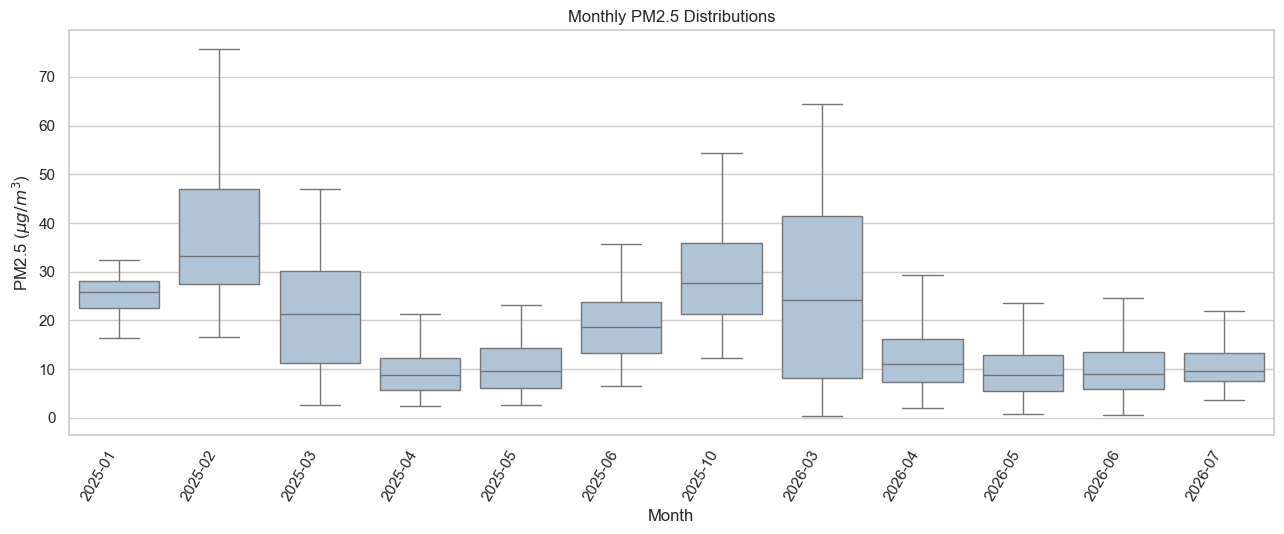

In [6]:
# Monthly PM2.5 distributions

plt.figure(figsize=(13, 5.5))

sns.boxplot(
    data=monthly_df,
    x="year_month",
    y=TARGET,
    showfliers=False,
    color="#A8C5DD",
)

plt.title("Monthly PM2.5 Distributions")
plt.xlabel("Month")
plt.ylabel(r"PM2.5 ($\mu g/m^3$)")
plt.xticks(rotation=60, ha="right")

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "monthly_pm25_distributions.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 1.2 Feature-Evaluation Protocol

The dataset is divided into two date-disjoint subsets:

1. **Development set:** used for feature and data-source evaluation in
   Notebook 3 and for model benchmarking in Notebook 4. All feature
   configurations are evaluated using date-grouped cross-validation
   within this subset.

2. **Common hold-out set:** excluded from all analyses in Notebook 3 and
   reserved for the final evaluation of the pre-specified benchmark
   methods and the optional CNN extension.

Complete dates are assigned to only one subset, preventing observations
from the same date from appearing in both subsets. Cross-validation
within the development set is also grouped by date. Model fitting and
metric calculation are unweighted; the month-aware split is used only
to improve the temporal representation of the two subsets.

In [7]:
# Create the development and common hold-out subsets

FINAL_TEST_SIZE = 0.20

development_df, final_test_df = (
    evaluation.balanced_month_group_split(
        analysis_df,
        time_column="time",
        test_size=FINAL_TEST_SIZE,
        random_state=RANDOM_STATE,
    )
)

development_dates = set(
    development_df["date_group"]
)

final_test_dates = set(
    final_test_df["date_group"]
)

shared_dates = (
    development_dates
    & final_test_dates
)

assert len(shared_dates) == 0

split_summary = pd.DataFrame(
    {
        "Subset": [
            "Development",
            "Common hold-out",
        ],
        "Samples": [
            len(development_df),
            len(final_test_df),
        ],
        "Independent dates": [
            development_df["date_group"].nunique(),
            final_test_df["date_group"].nunique(),
        ],
    }
)

split_summary["Percentage"] = (
    split_summary["Samples"]
    / len(analysis_df)
    * 100
)

display(
    split_summary.round(
        {"Percentage": 1}
    )
)

print(
    "Shared dates:",
    len(shared_dates),
)

,Subset,Samples,Independent dates,Percentage
0,Development,2544,148,80.0
1,Common hold-out,636,38,20.0


Shared dates: 0


## 2. Handcrafted ROI Image Feature Evaluation

This section evaluates whether handcrafted features extracted from the
fixed ROI contain information relevant to PM2.5 variation. The analyses
are conducted exclusively on the development set.

### 2.1 Feature Distributions

This section summarizes the distributions and scales of the handcrafted
ROI image features within the development set. Standardization is used
only to make the feature distributions visually comparable and does not
modify the stored feature values.

In [8]:
# Summary statistics of ROI image features

roi_summary = (
    development_df[config.IMAGE_FEATURES]
    .describe()
    .T[
        ["mean","std","min","25%","50%","75%","max",]
    ]
    .round(2)
    .rename(
        columns={
            "mean": "Mean",
            "std": "Std",
            "min": "Min",
            "25%": "Q1",
            "50%": "Median",
            "75%": "Q3",
            "max": "Max",
        }
    )
    .reset_index()
    .rename(columns={"index": "Feature"})
)

display(roi_summary)

,Feature,Mean,Std,Min,Q1,Median,Q3,Max
0,R_roi,102.20,19.72,54.22,86.12,106.99,116.98,154.71
1,G_roi,128.02,22.85,73.30,106.61,135.40,144.90,182.16
2,B_roi,153.29,23.65,98.17,131.96,160.28,171.40,207.43
3,R_std,40.38,7.92,11.12,34.21,40.95,45.89,75.69
4,G_std,44.95,10.43,11.58,34.45,47.49,52.89,75.32
5,B_std,51.85,11.09,17.26,41.11,54.96,60.33,77.86
6,S_mean,0.36,0.04,0.21,0.33,0.35,0.38,0.55
7,V_mean,0.61,0.09,0.40,0.52,0.63,0.68,0.81
8,colorfulness,37.56,8.85,19.56,31.41,35.74,42.76,68.87
9,sky_brightness,0.72,0.14,0.40,0.62,0.77,0.82,0.96


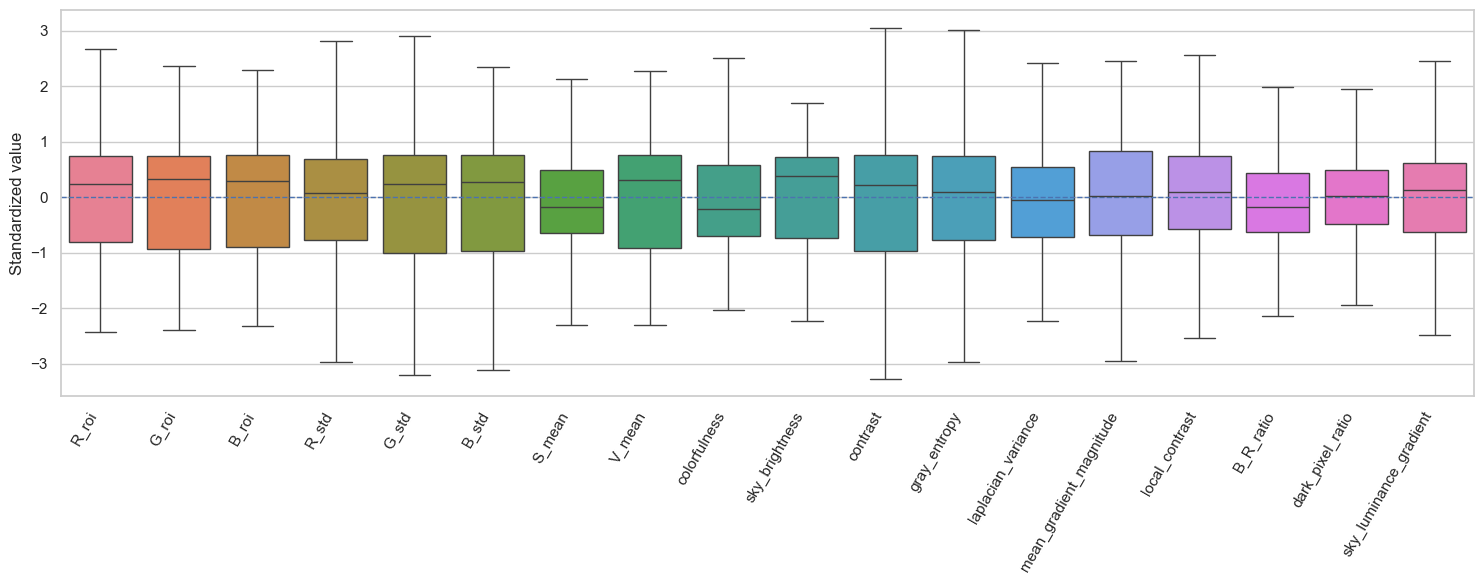

In [9]:
# Standardized boxplots of ROI image features

image_feature_data = development_df[config.IMAGE_FEATURES]

standardized_features = (image_feature_data - image_feature_data.mean()) / image_feature_data.std()

plt.figure(figsize=(15, 6))

sns.boxplot(data=standardized_features,showfliers=False,)

plt.axhline(y=0,linewidth=1,linestyle="--",)

plt.xlabel("")
plt.ylabel("Standardized value")
plt.xticks(rotation=60,ha="right",)

plt.tight_layout()

plt.savefig(RESULTS_DIR / "image_feature_distribution.png",dpi=300,bbox_inches="tight",)

plt.show()

### 2.2 Correlation Analysis

This section examines the linear and monotonic relationships between
handcrafted ROI image features and PM2.5 concentrations within the
development set using Pearson and Spearman correlation coefficients.

In [10]:
# Pearson and Spearman correlations with PM2.5

correlation_results = []

for feature in config.IMAGE_FEATURES:

    pearson_r, pearson_p = pearsonr(
        development_df[feature],
        development_df[TARGET],
    )

    spearman_rho, spearman_p = spearmanr(
        development_df[feature],
        development_df[TARGET],
    )

    correlation_results.append(
        {
            "Feature": feature,
            "Pearson r": pearson_r,
            "Pearson p": pearson_p,
            "Spearman rho": spearman_rho,
            "Spearman p": spearman_p,
        }
    )

correlation_results = pd.DataFrame(
    correlation_results
)

# Rank features by the absolute Pearson correlation
correlation_results = (
    correlation_results
    .assign(
        abs_pearson=lambda data:
        data["Pearson r"].abs()
    )
    .sort_values(
        "abs_pearson",
        ascending=False,
    )
    .drop(
        columns="abs_pearson"
    )
    .reset_index(drop=True)
)

# Use a separate display table so the numerical
# values remain available for plotting.
correlation_display = correlation_results.copy()

correlation_display["Pearson r"] = (
    correlation_display["Pearson r"]
    .round(3)
)

correlation_display["Spearman rho"] = (
    correlation_display["Spearman rho"]
    .round(3)
)

correlation_display["Pearson p"] = (
    correlation_display["Pearson p"]
    .map(lambda value: f"{value:.2e}")
)

correlation_display["Spearman p"] = (
    correlation_display["Spearman p"]
    .map(lambda value: f"{value:.2e}")
)

display(correlation_display)

,Feature,Pearson r,Pearson p,Spearman rho,Spearman p
0,dark_pixel_ratio,-0.545,6.24e-197,-0.494,2.20e-156
1,local_contrast,-0.514,8.96e-172,-0.415,1.34e-106
2,colorfulness,-0.491,1.58e-154,-0.489,2.31e-153
3,B_std,-0.407,7.75e-102,-0.313,4.94e-59
4,mean_gradient_magnitude,-0.386,5.01e-91,-0.299,8.28e-54
5,laplacian_variance,-0.385,1.95e-90,-0.315,1.04e-59
6,gray_entropy,-0.307,1.33e-56,-0.265,3.34e-42
7,G_std,-0.286,3.83e-49,-0.192,1.74e-22
8,contrast,-0.280,3.64e-47,-0.182,2.31e-20
9,R_std,-0.273,7.68e-45,-0.177,1.97e-19


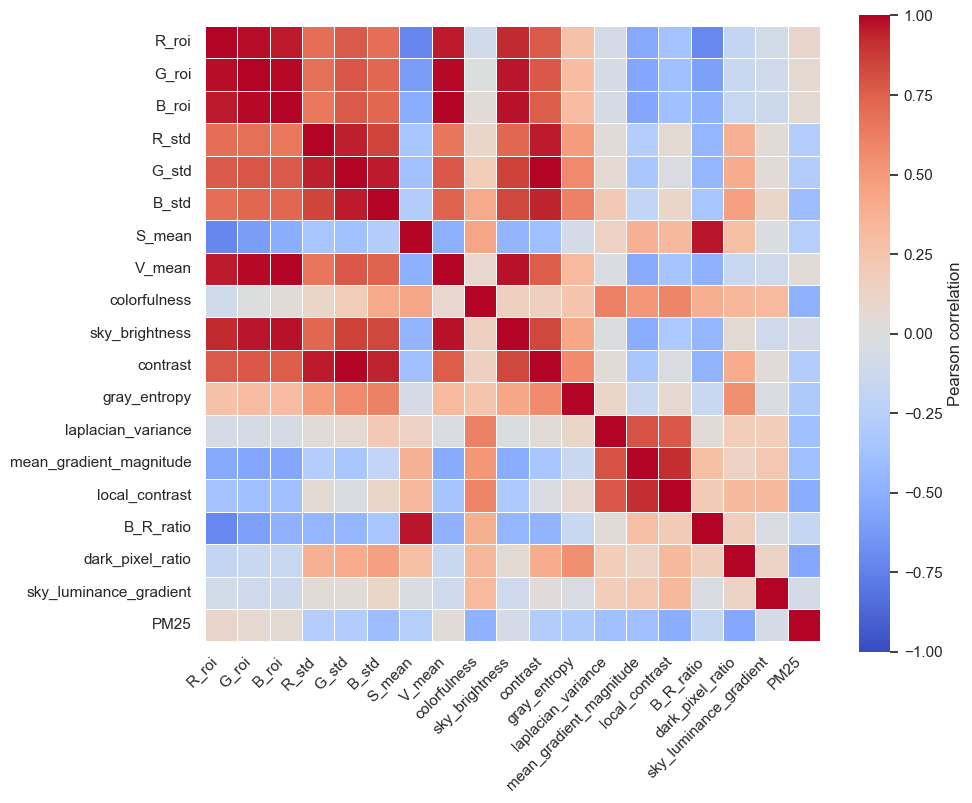

In [11]:
# Pearson correlation heatmap

correlation_matrix = (
    development_df[
        config.IMAGE_FEATURES + [TARGET]
    ]
    .corr(method="pearson")
)

plt.figure(figsize=(10, 9))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.6,
    vmin=-1,
    vmax=1,
    cbar_kws={
        "label": "Pearson correlation","shrink":0.85,
    },
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "image_feature_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

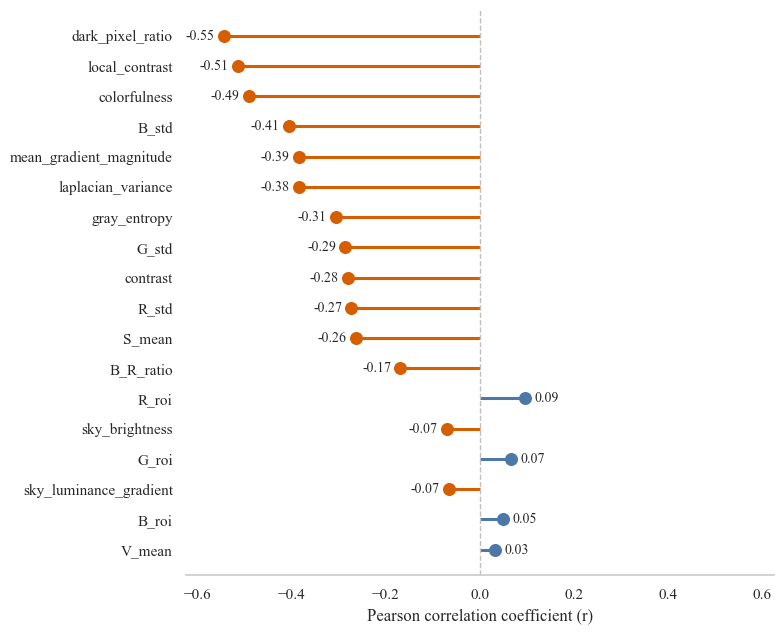

In [12]:
# Correlation ranking

fig = features_plots.plot_correlation_ranking(
    correlation_results=correlation_results,
    output_path=RESULTS_DIR / "image_feature_correlation_ranking.png",
)

plt.show()

### 2.3 Image Feature Group Evaluation

The predictive value of the handcrafted ROI image feature groups is
evaluated using Ridge regression and Random Forest. Ridge represents a
linear modelling approach, whereas Random Forest can capture nonlinear
relationships and feature interactions.

All feature configurations are evaluated using the same unweighted,
date-grouped cross-validation folds within the development set. The
common hold-out set is not used in this analysis. The two models serve
as analytical tools for feature-group evaluation rather than as the
main model benchmark, which is presented in Notebook 4.


In [13]:
# Define ROI image feature groups

image_feature_sets = {
    "Color": config.COLOR_FEATURES,
    "Contrast": config.CONTRAST_TEXTURE_FEATURES,
    "Visibility": config.HAZE_VISIBILITY_FEATURES,
    "All Image Features": config.IMAGE_FEATURES,
}

feature_group_summary = pd.DataFrame(
    {
        "Feature Group": list(image_feature_sets.keys()),
        "Variables": [
            len(features)
            for features in image_feature_sets.values()
        ],
    }
)

display(feature_group_summary)

,Feature Group,Variables
0,Color,10
1,Contrast,5
2,Visibility,3
3,All Image Features,18


In [14]:
# Models used for image feature-group evaluation

ridge_model = Pipeline(
    [
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "model",
            Ridge(alpha=1.0),
        ),
    ]
)

random_forest_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

models = {
    "Ridge": ridge_model,
    "Random Forest": random_forest_model,
}

image_group_results = []
image_group_fold_results = []

for model_name, model in models.items():

    for (
        feature_set_name,
        feature_list,
    ) in image_feature_sets.items():

        (
            summary,
            fold_results,
            _,
            _,
        ) = evaluation.evaluate_feature_set(
            model=model,
            model_name=model_name,
            feature_set_name=feature_set_name,
            feature_list=feature_list,
            development_df=development_df,

            # Not accessed because evaluate_test=False.
            test_df=final_test_df,

            target=TARGET,
            n_splits=N_SPLITS,
            random_state=RANDOM_STATE,

            # Keep complete dates in the same fold.
            group_column="date_group",

            # Use unweighted fitting and evaluation.
            balance_column=None,

            # Feature-group evaluation uses development CV only.
            evaluate_test=False,
        )

        image_group_results.append(
            summary
        )

        image_group_fold_results.append(
            fold_results.assign(
                Model=model_name,
                **{
                    "Feature Set":
                    feature_set_name
                },
            )
        )

image_group_results = pd.concat(
    image_group_results,
    ignore_index=True,
)

image_group_fold_results = pd.concat(
    image_group_fold_results,
    ignore_index=True,
)

display(
    image_group_results.round(
        {
            "CV MAE": 3,
            "CV MAE Std": 3,
            "CV RMSE": 3,
            "CV RMSE Std": 3,
            "CV R2": 3,
            "CV R2 Std": 3,
        }
    )
)

,Model,Feature Set,Variables,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R2,CV R2 Std
0,Ridge,Color,10,6.496,0.669,8.957,0.942,0.476,0.076
1,Ridge,Contrast,5,7.022,0.596,9.865,0.847,0.367,0.049
2,Ridge,Visibility,3,7.767,0.613,10.463,1.031,0.289,0.057
3,Ridge,All Image Features,18,6.213,0.654,8.629,1.026,0.515,0.069
4,Random Forest,Color,10,6.031,0.531,8.736,0.838,0.504,0.040
5,Random Forest,Contrast,5,5.836,0.393,8.477,0.584,0.527,0.078
6,Random Forest,Visibility,3,6.174,0.772,8.992,1.320,0.474,0.095
7,Random Forest,All Image Features,18,5.406,0.503,7.944,0.922,0.590,0.049


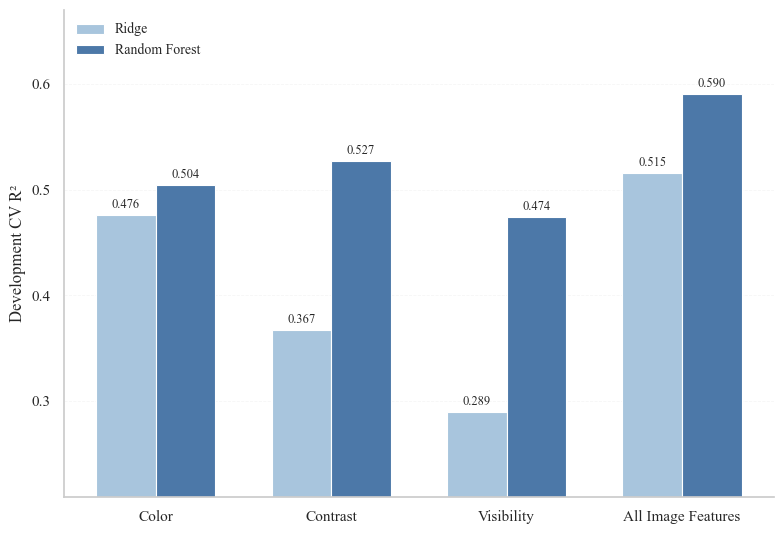

In [15]:
# Development CV performance of ROI image feature groups

fig = features_plots.plot_image_feature_group_performance(
    image_group_results=image_group_results,
    output_path=(
        RESULTS_DIR
        / "image_feature_group_cv_r2.png"
    ),
    metric="CV R2",
)

plt.show()

### 2.4 Exploratory Clean-Air Reference Normalization

This exploratory analysis investigates whether normalizing the
handcrafted ROI image features relative to clean-air observations
improves their predictive value.

Within each cross-validation fold, clean-air reference observations are
operationally defined as the lowest 20% of PM2.5 concentrations in the
training portion. Reference statistics are estimated exclusively from
the training data and conditioned on season and daytime status where
sufficient samples are available. No validation targets are used to
construct the reference, thereby preventing target leakage.

In [16]:
# Compare raw and clean-reference normalized image features

raw_image_result = (
    image_group_results[
        (
            image_group_results["Model"]
            == "Random Forest"
        )
        & (
            image_group_results["Feature Set"]
            == "All Image Features"
        )
    ]
    .copy()
)

raw_image_result[
    "Representation"
] = "Raw image features"

(
    normalized_image_result,
    normalized_fold_results,
    _,
    _,
) = evaluation.evaluate_clean_reference_feature_set(
    model=random_forest_model,
    model_name="Random Forest",
    feature_list=config.IMAGE_FEATURES,
    development_df=development_df,

    # Required by the function interface but not accessed
    # because evaluate_test=False.
    test_df=final_test_df,

    target=TARGET,
    n_splits=N_SPLITS,
    random_state=RANDOM_STATE,
    group_column="date_group",
    # Use the same unweighted protocol as the raw-feature evaluation.
    balance_column=None,
    clean_quantile=0.20,
    evaluate_test=False,
)

normalized_image_result[
    "Representation"
] = "Clean-reference normalized"

clean_reference_results = pd.concat(
    [
        raw_image_result,
        normalized_image_result,
    ],
    ignore_index=True,
)

display(
    clean_reference_results[
        [
            "Representation",
            "CV MAE",
            "CV MAE Std",
            "CV RMSE",
            "CV RMSE Std",
            "CV R2",
            "CV R2 Std",
        ]
    ]
    .round(3)
)

,Representation,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R2,CV R2 Std
0,Raw image features,5.406,0.503,7.944,0.922,0.590,0.049
1,Clean-reference normalized,5.514,0.474,8.179,0.899,0.566,0.036


## 3. Multi-Source Data Fusion Evaluation

This section evaluates the contribution of different data sources and
investigates whether multi-source fusion improves PM2.5 estimation
relative to using handcrafted ROI image features alone.

### 3.1 Progressive Data-Source Configurations

Four progressively expanded feature configurations are evaluated. Each configuration adds a new information source while retaining the features included in the previous configuration.

In [17]:
# Define progressive multi-source feature sets

fusion_feature_sets = (
    config.FUSION_FEATURE_SETS
)

feature_descriptions = {
    "Image": (
        "Handcrafted ROI image features"
    ),
    "Image + ERA5": (
        "Handcrafted ROI image features and "
        "ERA5 meteorological variables"
    ),
    "Image + ERA5 + ARPA": (
        "Handcrafted ROI image features, ERA5 variables, "
        "and local ARPA meteorological observations"
    ),
    "All Features": (
        "Image, ERA5, ARPA, and temporal features"
    ),
}

fusion_feature_summary = pd.DataFrame(
    {
        "Feature Set": list(
            fusion_feature_sets.keys()
        ),
        "Description": [
            feature_descriptions[name]
            for name in fusion_feature_sets
        ],
        "Variables": [
            len(features)
            for features
            in fusion_feature_sets.values()
        ],
    }
)

display(fusion_feature_summary)

,Feature Set,Description,Variables
0,Image,Handcrafted ROI image features,18
1,Image + ERA5,Handcrafted ROI image features and ERA5 meteor...,36
2,Image + ERA5 + ARPA,"Handcrafted ROI image features, ERA5 variables...",43
3,All Features,"Image, ERA5, ARPA, and temporal features",55


### 3.2 Incremental Multi-Source Fusion

The effect of progressively adding ERA5, ARPA, and temporal predictors
is evaluated using the same analytical models and unweighted,
date-grouped cross-validation protocol adopted for the image
feature-group analysis.

All configurations are evaluated exclusively within the development
set. The common hold-out set is not used in this section.

In [18]:
# Evaluate progressive multi-source feature fusion

fusion_results = []
fusion_fold_results = []

for model_name, model in models.items():

    for (
        feature_set_name,
        feature_list,
    ) in fusion_feature_sets.items():

        (
            summary,
            fold_results,
            _,
            _,
        ) = evaluation.evaluate_feature_set(
            model=model,
            model_name=model_name,
            feature_set_name=feature_set_name,
            feature_list=feature_list,
            development_df=development_df,

            # Required by the interface but not accessed
            # because evaluate_test=False.
            test_df=final_test_df,

            target=TARGET,
            n_splits=N_SPLITS,
            random_state=RANDOM_STATE,
            group_column="date_group",
            
            # Use unweighted fitting and evaluation.
            balance_column=None,
            evaluate_test=False,
        )

        fusion_results.append(
            summary
        )

        fusion_fold_results.append(
            fold_results.assign(
                Model=model_name,
                **{
                    "Feature Set":
                    feature_set_name
                },
            )
        )

fusion_results = pd.concat(
    fusion_results,
    ignore_index=True,
)

fusion_fold_results = pd.concat(
    fusion_fold_results,
    ignore_index=True,
)

display(
    fusion_results.round(
        {
            "CV MAE": 3,
            "CV MAE Std": 3,
            "CV RMSE": 3,
            "CV RMSE Std": 3,
            "CV R2": 3,
            "CV R2 Std": 3,
        }
    )
)

,Model,Feature Set,Variables,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R2,CV R2 Std
0,Ridge,Image,18,6.213,0.654,8.629,1.026,0.515,0.069
1,Ridge,Image + ERA5,36,5.997,0.441,7.950,0.659,0.586,0.066
2,Ridge,Image + ERA5 + ARPA,43,6.037,0.458,7.990,0.660,0.582,0.065
3,Ridge,All Features,55,5.262,0.361,6.987,0.403,0.678,0.058
4,Random Forest,Image,18,5.406,0.503,7.944,0.922,0.590,0.049
5,Random Forest,Image + ERA5,36,4.991,0.351,7.013,0.545,0.678,0.040
6,Random Forest,Image + ERA5 + ARPA,43,4.929,0.288,6.907,0.391,0.687,0.039
7,Random Forest,All Features,55,4.760,0.279,6.627,0.352,0.712,0.035


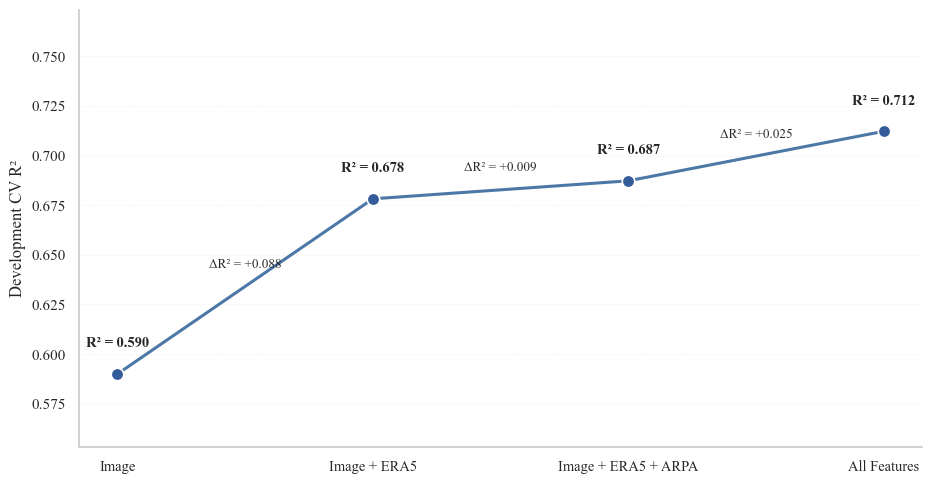

In [19]:
# Development CV performance of progressive feature fusion

fig = features_plots.plot_progressive_feature_fusion(
    fusion_results=fusion_results,
    output_path=(
        RESULTS_DIR
        / "progressive_fusion_cv.png"
    ),
    model_name="Random Forest",
    metric="CV R2",
)

plt.show()

### 3.3 Leave-One-Source-Out Ablation

Because the progressive fusion results may depend on the order in which
data sources are added, a leave-one-source-out ablation is used to
evaluate the contribution of each source within the complete feature
configuration.

Starting from the complete feature set, image, ERA5, ARPA, and temporal
predictors are removed one source at a time. All configurations are
evaluated using Random Forest under the same unweighted, date-grouped
development cross-validation protocol. The common hold-out set is not
used.

In [20]:
# Define leave-one-source-out feature configurations

ablation_feature_sets = {
    "All Features": (
        config.ALL_FEATURES
    ),
    "All - Image": (
        config.ERA5_FEATURES
        + config.ARPA_FEATURES
        + config.TEMPORAL_FEATURES
    ),
    "All - ERA5": (
        config.IMAGE_FEATURES
        + config.ARPA_FEATURES
        + config.TEMPORAL_FEATURES
    ),
    "All - ARPA": (
        config.IMAGE_FEATURES
        + config.ERA5_FEATURES
        + config.TEMPORAL_FEATURES
    ),
    "All - Temporal": (
        config.IMAGE_FEATURES
        + config.ERA5_FEATURES
        + config.ARPA_FEATURES
    ),
}

ablation_feature_summary = pd.DataFrame(
    {
        "Feature Set": list(
            ablation_feature_sets.keys()
        ),
        "Variables": [
            len(features)
            for features
            in ablation_feature_sets.values()
        ],
    }
)

display(ablation_feature_summary)

,Feature Set,Variables
0,All Features,55
1,All - Image,37
2,All - ERA5,37
3,All - ARPA,48
4,All - Temporal,43


In [21]:
# Evaluate leave-one-source-out ablation

ablation_results = []
ablation_fold_results = []

for (
    feature_set_name,
    feature_list,
) in ablation_feature_sets.items():

    (
        summary,
        fold_results,
        _,
        _,
    ) = evaluation.evaluate_feature_set(
        model=random_forest_model,
        model_name="Random Forest",
        feature_set_name=feature_set_name,
        feature_list=feature_list,
        development_df=development_df,

        # Required by the interface but not accessed
        # because evaluate_test=False.
        test_df=final_test_df,

        target=TARGET,
        n_splits=N_SPLITS,
        random_state=RANDOM_STATE,
        group_column="date_group",

        # Use unweighted fitting and evaluation.
        balance_column=None,
        evaluate_test=False,
    )

    ablation_results.append(
        summary
    )

    ablation_fold_results.append(
        fold_results.assign(
            **{
                "Feature Set":
                feature_set_name
            }
        )
    )

ablation_results = pd.concat(
    ablation_results,
    ignore_index=True,
)

ablation_fold_results = pd.concat(
    ablation_fold_results,
    ignore_index=True,
)

all_feature_row = (
    ablation_results[
        ablation_results["Feature Set"]
        == "All Features"
    ]
    .iloc[0]
)

all_feature_r2 = (
    all_feature_row["CV R2"]
)

all_feature_rmse = (
    all_feature_row["CV RMSE"]
)

ablation_results[
    "CV R2 Change"
] = (
    ablation_results["CV R2"]
    - all_feature_r2
)

ablation_results[
    "CV RMSE Change"
] = (
    ablation_results["CV RMSE"]
    - all_feature_rmse
)

display(
    ablation_results[
        [
            "Feature Set",
            "Variables",
            "CV MAE",
            "CV RMSE",
            "CV R2",
            "CV R2 Change",
            "CV RMSE Change",
        ]
    ]
    .round(3)
)

,Feature Set,Variables,CV MAE,CV RMSE,CV R2,CV R2 Change,CV RMSE Change
0,All Features,55,4.760,6.627,0.712,0.000,0.000
1,All - Image,37,5.133,7.225,0.658,-0.054,0.598
2,All - ERA5,37,4.766,6.693,0.704,-0.008,0.066
3,All - ARPA,48,4.805,6.715,0.705,-0.007,0.088
4,All - Temporal,43,4.929,6.907,0.687,-0.025,0.280
